# **Install Dependencies & Upload Data**



In [ ]:
# Run this cell to initialize the environment and upload your CSV files directly.

!pip install mne -q
!pip install mne > /dev/null 2>&1

import os
import glob
import pandas as pd
import numpy as np
from scipy import signal
import mne
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Suppress verbose MNE logging
mne.set_log_level('ERROR')
print("✅ Environment initialized. Please click below to upload your CSV file(s):")

# This triggers the browser's file selection dialog
uploaded = files.upload()

✅ Environment initialized. Please click below to upload your CSV file(s):


Saving Offline_data_math_20260808_152400.csv to Offline_data_math_20260808_152400 (1).csv
Saving Offline_data_math_20260808_152743.csv to Offline_data_math_20260808_152743 (1).csv
Saving Offline_data_math_20260808_153146.csv to Offline_data_math_20260808_153146 (1).csv
Saving Offline_data_words_20260807_235853.csv to Offline_data_words_20260807_235853 (1).csv
Saving Offline_data_words_20260808_000300.csv to Offline_data_words_20260808_000300 (1).csv
Saving Offline_data_words_20260808_000654.csv to Offline_data_words_20260808_000654 (1).csv


# **Subject and Task Configuration**

In [ ]:
# Select the evaluation task. The script will automatically scan the files you just uploaded.

task_type = "words" # @param ["math", "words"]
subject_id = "111" # Used for naming the final output file

SAMPLING_RATE = 256
EEG_CHANNELS = ["TP9", "AF7", "AF8", "TP10"]
EPOCH_LENGTH_SEC = 2.0

# Files uploaded via files.upload() are saved in the default '/content' directory
target_dir = "/content"

print("=" * 60)
print(f"🧠 Selected Task: {task_type.upper()}")
print("=" * 60)

# Locate matching session CSV files in the current Colab directory
all_csv_files = glob.glob(os.path.join(target_dir, "*.csv"))
files_to_process = [f for f in all_csv_files if task_type.lower() in os.path.basename(f).lower()]

if not files_to_process:
    print(f"❌ Warning: No uploaded CSV files found matching the task '{task_type}'.")
    print("Please run Cell 1 again to ensure the files uploaded successfully.")
else:
    print(f"🔍 Found {len(files_to_process)} session file(s) for task '{task_type}':")
    for f in files_to_process:
        print(f"   -> {os.path.basename(f)}")

🧠 Selected Task: WORDS
🔍 Found 3 session file(s) for task 'words':
   -> Offline_data_words_20260808_000654.csv
   -> Offline_data_words_20260807_235853.csv
   -> Offline_data_words_20260808_000300.csv


# **Biological Validation (Pass 1 - Berger Effect)**

In [ ]:
# Verifies cortical signal integrity by ensuring Alpha band power (8-12 Hz) surges
# when eyes are closed (Marker 2) compared to eyes open (Marker 1).

def clean_flagged_data(df):
    if 'Artifact_Flag' in df.columns:
        df = df[df['Artifact_Flag'] == 0]
    if 'Rhythm_Flag' in df.columns:
        df = df[df['Rhythm_Flag'] == 0]
    return df

def apply_mne_pipeline(df, fs):
    """Applies Notch, Bandpass (1-40 Hz), and ICA blink scrubbing using AF7."""
    eeg_data = df[EEG_CHANNELS].values.T
    info = mne.create_info(ch_names=EEG_CHANNELS, sfreq=fs, ch_types='eeg')
    raw = mne.io.RawArray(eeg_data, info)

    raw.notch_filter(freqs=50.0)
    raw.filter(l_freq=1.0, h_freq=40.0)

    try:
        ica = mne.preprocessing.ICA(n_components=3, random_state=42, max_iter='auto')
        ica.fit(raw)
        eog_indices, _ = ica.find_bads_eog(raw, ch_name='AF7')
        ica.exclude = eog_indices
        raw = ica.apply(raw)
    except Exception:
        pass

    return raw.get_data().T

def verify_berger_effect(df, fs, filename):
    m1_data = df[df['Marker'] == 1]
    m2_data = df[df['Marker'] == 2]

    if m1_data.empty or m2_data.empty:
        return False, f"[{filename}] ⚠️ Skipped: Missing Marker 1 (Eyes Open) or 2 (Eyes Closed) baseline."

    try:
        m1_clean = m1_data[['TP9', 'TP10']].values
        m2_clean = m2_data[['TP9', 'TP10']].values

        freqs, psd_m1 = signal.welch(m1_clean, fs=fs, nperseg=fs * 2, axis=0)
        _, psd_m2 = signal.welch(m2_clean, fs=fs, nperseg=fs * 2, axis=0)

        alpha_idx = np.logical_and(freqs >= 8, freqs <= 12)

        # Updated to np.trapezoid
        m1_alpha = np.mean(np.trapezoid(psd_m1[alpha_idx], freqs[alpha_idx], axis=0))
        m2_alpha = np.mean(np.trapezoid(psd_m2[alpha_idx], freqs[alpha_idx], axis=0))

        surge_ratio = m2_alpha / (m1_alpha + 1e-9)
        if surge_ratio > 1.2:
            return True, f"[{filename}] ✅ Passed: Alpha surged by {surge_ratio:.2f}x (Eyes Closed vs Open)."
        else:
            return False, f"[{filename}] ❌ Failed: Alpha ratio was {surge_ratio:.2f}x (Low cortical contact)."
    except Exception as e:
        return False, f"[{filename}] ⚠️ Berger check error: {e}"

# Run Pass 1 validation
passed_files = []
print("🧪 Running Biological Validation on baseline recordings...")
for filepath in files_to_process:
    fname = os.path.basename(filepath)
    raw_df = pd.read_csv(filepath)
    raw_df = clean_flagged_data(raw_df)
    clean_eeg = apply_mne_pipeline(raw_df, SAMPLING_RATE)
    raw_df.loc[:, EEG_CHANNELS] = clean_eeg

    is_valid, msg = verify_berger_effect(raw_df, SAMPLING_RATE, fname)
    print(f"  {msg}")
    if is_valid:
        passed_files.append(filepath)

# Allow processing if files passed, otherwise fallback to all files for demonstration
valid_files = passed_files if len(passed_files) > 0 else files_to_process
print(f"\n📊 {len(valid_files)} file(s) ready for Feature Extraction.")

🧪 Running Biological Validation on baseline recordings...
  [Offline_data_words_20260808_000654.csv] ✅ Passed: Alpha surged by 1.45x (Eyes Closed vs Open).
  [Offline_data_words_20260807_235853.csv] ✅ Passed: Alpha surged by 1.44x (Eyes Closed vs Open).
  [Offline_data_words_20260808_000300.csv] ✅ Passed: Alpha surged by 1.77x (Eyes Closed vs Open).

📊 3 file(s) ready for Feature Extraction.


# **Biological Validation (Pass 2 - ERD Task Responsiveness)**

In [ ]:
# Verifies neural engagement by measuring Event-Related Desynchronization (ERD).
# An active cognitive/motor task (Marker 4) should cause a noticeable power drop
# (desynchronization) in the Alpha/Mu band (8-12 Hz) or Beta band (13-30 Hz) compared to Rest (Marker 3).

def verify_erd_effect(df, fs, filename, channels=["AF7", "AF8", "TP9", "TP10"]):
    """
    Calculates ERD percentage: ((Power_Active - Power_Rest) / Power_Rest) * 100
    A negative ERD percentage confirms true biological desynchronization.
    """
    rest_data = df[df['Marker'] == 3]
    active_data = df[df['Marker'] == 4]

    if rest_data.empty or active_data.empty:
        return False, f"[{filename}] ⚠️ Skipped: Missing Marker 3 (Rest) or Marker 4 (Active Task)."

    try:
        rest_signals = rest_data[channels].values
        active_signals = active_data[channels].values

        freqs, psd_rest = signal.welch(rest_signals, fs=fs, nperseg=fs * 2, axis=0)
        _, psd_active = signal.welch(active_signals, fs=fs, nperseg=fs * 2, axis=0)

        # Focus on Alpha/Mu rhythm (8-12 Hz) for desynchronization
        alpha_idx = np.logical_and(freqs >= 8, freqs <= 12)

        pwr_rest = np.mean(np.trapezoid(psd_rest[alpha_idx], freqs[alpha_idx], axis=0))
        pwr_active = np.mean(np.trapezoid(psd_active[alpha_idx], freqs[alpha_idx], axis=0))

        # Standard Pfurtscheller ERD formula: % drop relative to rest
        erd_percent = ((pwr_active - pwr_rest) / (pwr_rest + 1e-9)) * 100

        # Threshold: At least a 10% desynchronization drop (ERD <= -10%)
        if erd_percent <= -10.0:
            return True, f"[{filename}] ✅ Passed: Significant ERD detected ({erd_percent:.1f}% Alpha power drop during task)."
        elif erd_percent < 0:
            return True, f"[{filename}] ⚠️ Borderline: Weak ERD detected ({erd_percent:.1f}% drop)."
        else:
            return False, f"[{filename}] ❌ Failed: No ERD observed ({erd_percent:+.1f}% power change - potential muscle artifact or lack of focus)."

    except Exception as e:
        return False, f"[{filename}] ⚠️ ERD validation error: {e}"


# --- Run Pass 2 Validation across all session files ---
print("🧪 Running Pass 2 (ERD / Task Responsiveness Validation)...")
erd_passed_files = []

for filepath in files_to_process:
    fname = os.path.basename(filepath)
    raw_df = pd.read_csv(filepath)
    raw_df = clean_flagged_data(raw_df)
    clean_eeg = apply_mne_pipeline(raw_df, SAMPLING_RATE)
    raw_df.loc[:, EEG_CHANNELS] = clean_eeg

    is_valid, msg = verify_erd_effect(raw_df, SAMPLING_RATE, fname, channels=EEG_CHANNELS)
    print(f"  {msg}")
    if is_valid:
        erd_passed_files.append(filepath)

print(f"\n📊 {len(erd_passed_files)} of {len(files_to_process)} session file(s) passed ERD biological screening.")

🧪 Running Pass 2 (ERD / Task Responsiveness Validation)...
  [Offline_data_words_20260808_000654.csv] ❌ Failed: No ERD observed (+2.0% power change - potential muscle artifact or lack of focus).
  [Offline_data_words_20260807_235853.csv] ✅ Passed: Significant ERD detected (-12.8% Alpha power drop during task).
  [Offline_data_words_20260808_000300.csv] ✅ Passed: Significant ERD detected (-27.2% Alpha power drop during task).

📊 2 of 3 session file(s) passed ERD biological screening.


# **Visual Inspection & Electrode Selection**

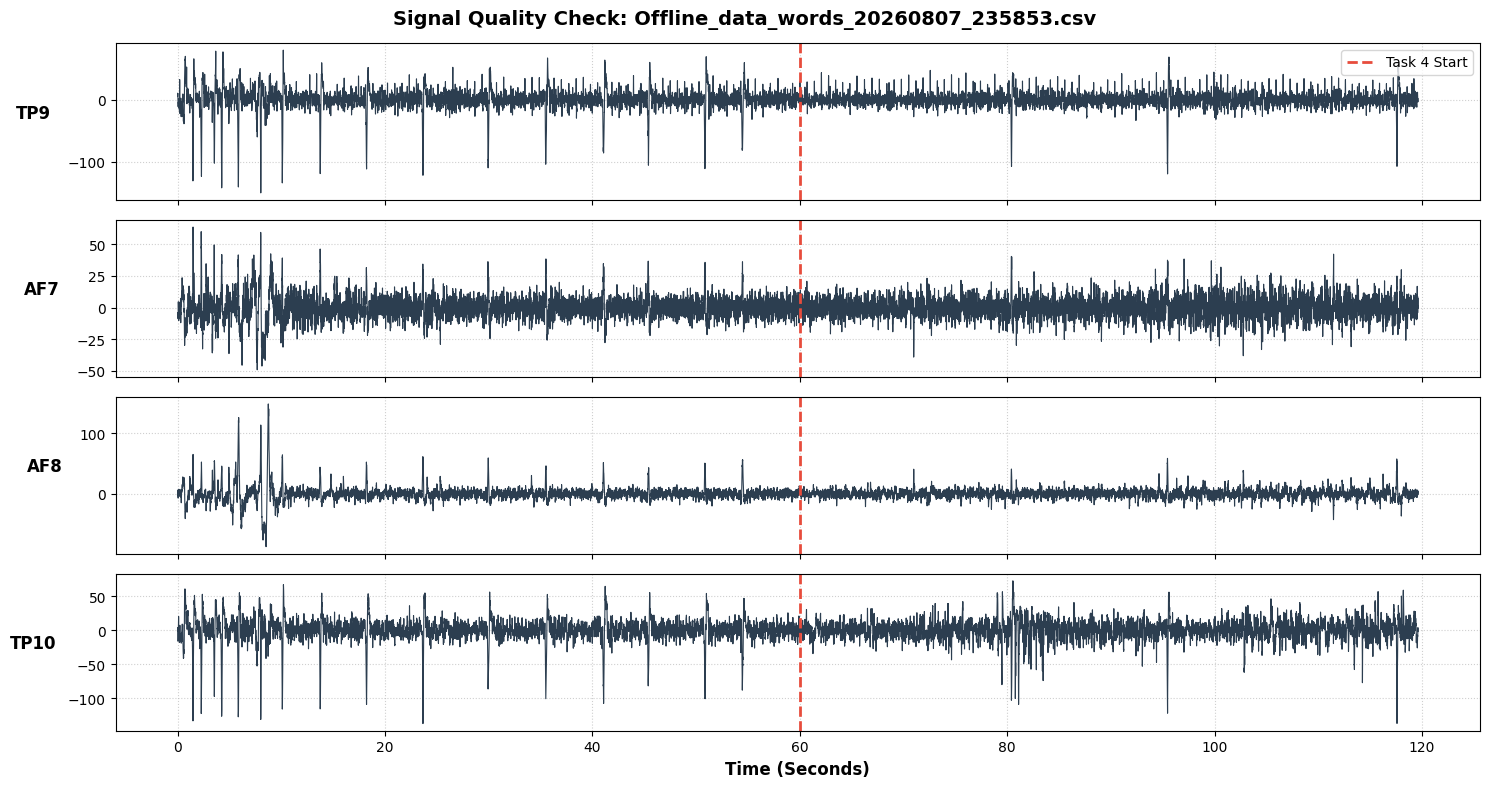

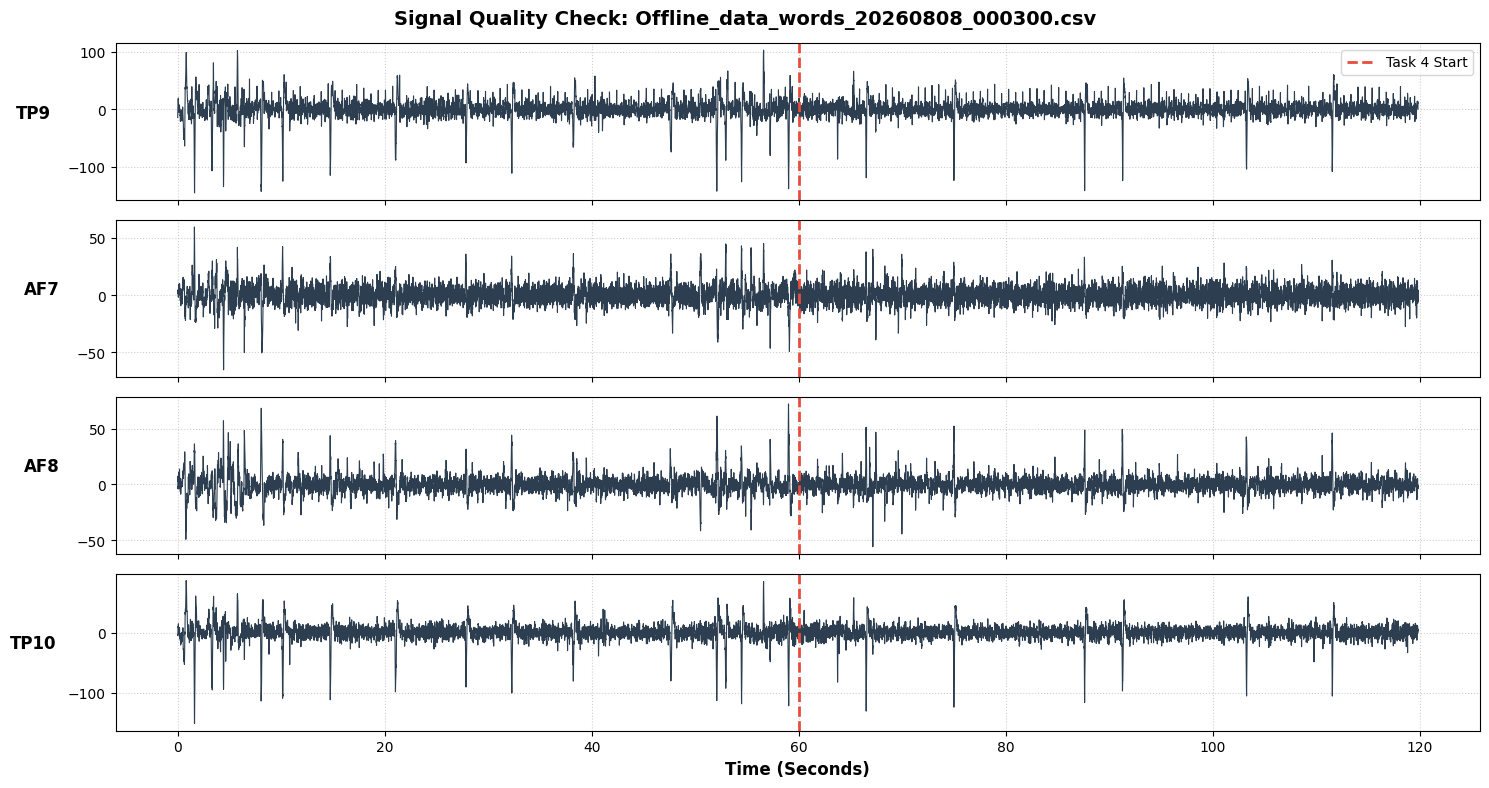

👉 Proceeding to Feature Extraction with 2 validated file(s) and channels: ['TP9', 'AF7', 'AF8', 'TP10']


In [ ]:
# Run this cell to plot the 120-second active/rest phases for each session.
# Review the signal quality and remove any excessively noisy channels from the list below.

# Failsafe: Filter to strictly include files that passed BOTH Pass 1 (Berger) and Pass 2 (ERD)
try:
    if 'valid_files' in locals() and 'erd_passed_files' in locals():
        # Intersection: only keep files present in both success lists
        fully_validated_files = [f for f in files_to_process if f in valid_files and f in erd_passed_files]
    else:
        print("❌ Error: Please run both Pass 1 and Pass 2 validation steps first.")
        fully_validated_files = files_to_process

    if not fully_validated_files:
        print("⚠️ Warning: No files passed both validations. Falling back to all files for demonstration.")
        fully_validated_files = files_to_process
except NameError:
    fully_validated_files = []

all_channels = ["TP9", "AF7", "AF8", "TP10"]

# Plotting the data for visual inspection
for file in fully_validated_files:
    df = pd.read_csv(file)
    df = clean_flagged_data(df)

    # Apply filtering so students evaluate the clean signal
    clean_eeg = apply_mne_pipeline(df, SAMPLING_RATE)
    df.loc[:, all_channels] = clean_eeg

    # Isolate Rest (Marker 3) and Active (Marker 4)
    task_df = df[df['Marker'].isin([3, 4])].copy()
    time_axis = np.arange(len(task_df)) / SAMPLING_RATE

    # Calculate where the task marker shifts from 3 to 4
    transition_time = len(task_df[task_df['Marker'] == 3]) / SAMPLING_RATE

    fig, axes = plt.subplots(len(all_channels), 1, figsize=(15, 8), sharex=True)
    fig.suptitle(f"Signal Quality Check: {os.path.basename(file)}", fontsize=14, fontweight='bold')

    for ax, ch in zip(axes, all_channels):
        ax.plot(time_axis, task_df[ch], color='#2c3e50', linewidth=0.8)
        ax.axvline(x=transition_time, color='#e74c3c', linestyle='--', linewidth=2, label='Task 4 Start' if ch == all_channels[0] else "")
        ax.set_ylabel(ch, fontsize=12, fontweight='bold', rotation=0, labelpad=25)
        ax.grid(True, linestyle=':', alpha=0.6)
        if ch == all_channels[0]:
            ax.legend(loc='upper right')

    axes[-1].set_xlabel("Time (Seconds)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Override valid_files so Step 4 (Feature Extraction) strictly uses the fully validated list
valid_files = fully_validated_files

# Electrode Selection
# Edit the array below to drop any channels that look entirely like noise before proceeding to Step 4.
EEG_CHANNELS = ["TP9", "AF7", "AF8", "TP10"] # E.g., change to ["TP9", "TP10"] to drop frontal electrodes

print(f"👉 Proceeding to Feature Extraction with {len(fully_validated_files)} validated file(s) and channels: {EEG_CHANNELS}")

# **Preprocessing & Visual Inspection (Before vs. After)**

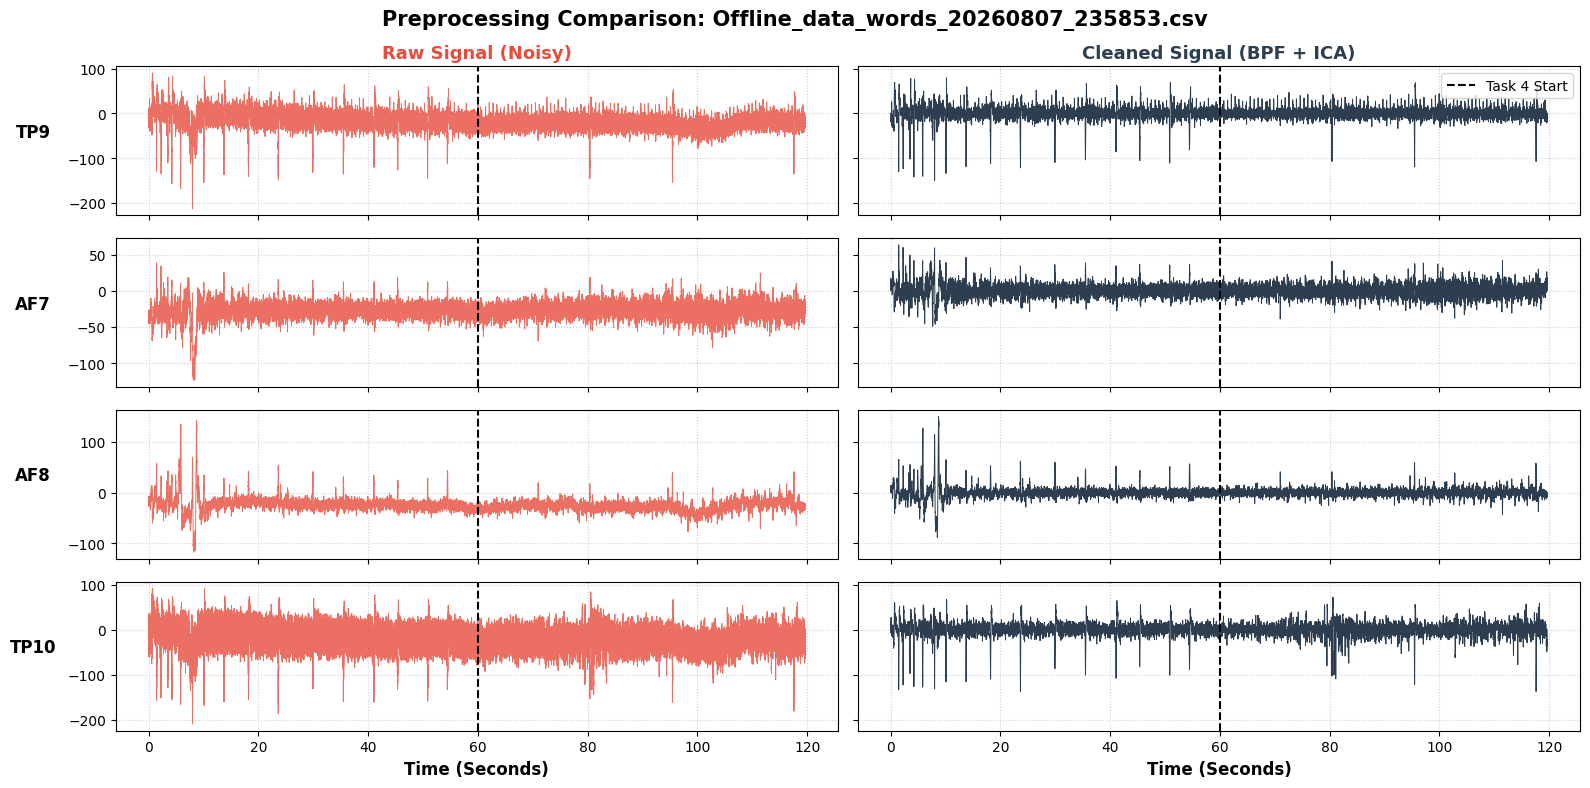

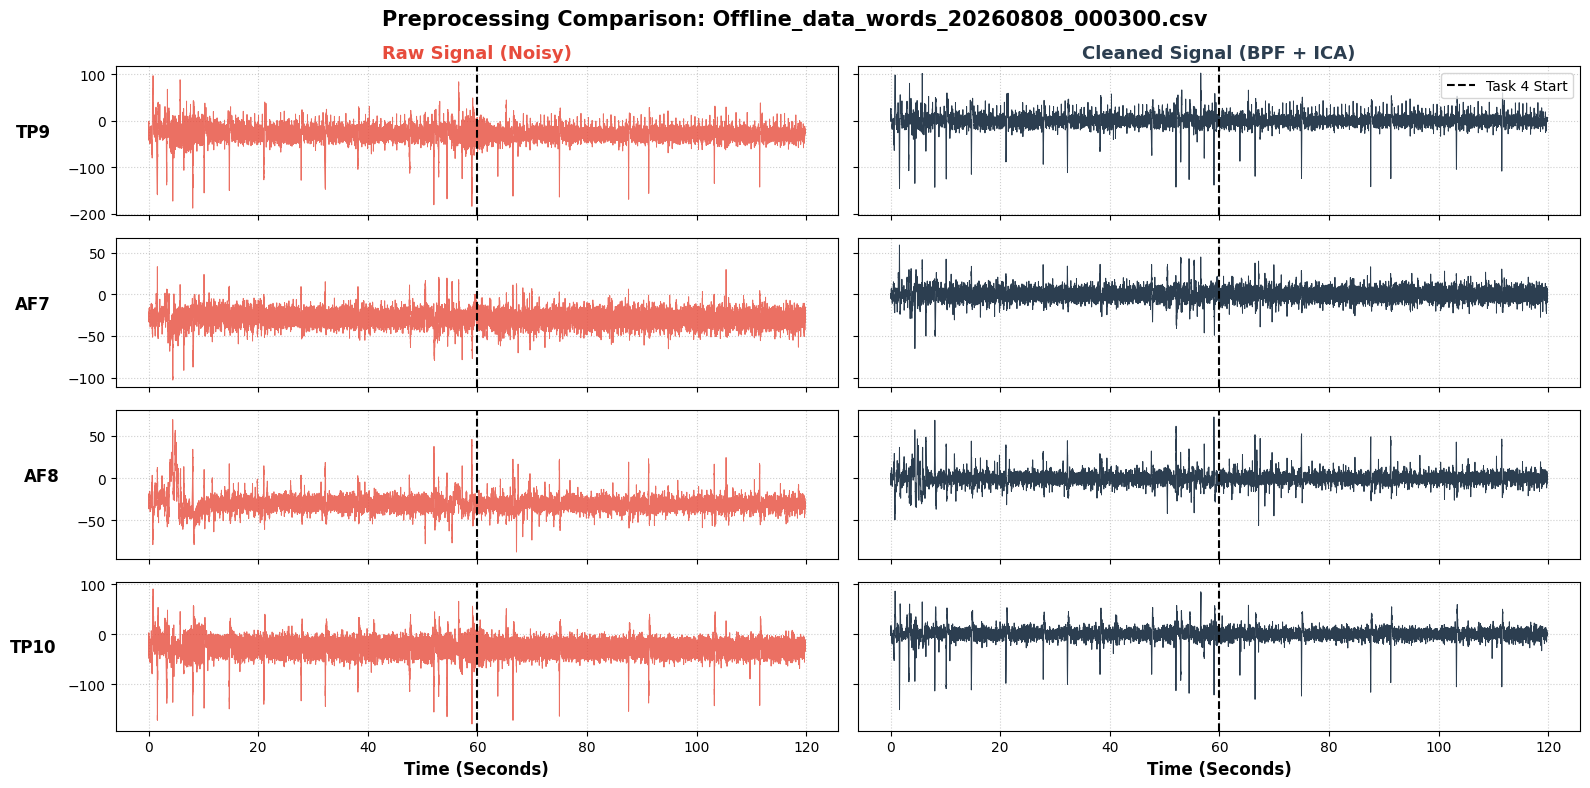

👉 Proceeding to Feature Extraction with: ['TP9', 'AF7', 'AF8', 'TP10']


In [ ]:
# Run this cell to apply a Bandpass Filter (BPF) and Independent Component Analysis (ICA)
# to remove noise and eye blinks, then plot a Before & After comparison.

# Failsafe: Fallback to Step 2 files if Step 3 was skipped
if 'valid_files' not in locals() and 'erd_passed_files' in locals():
    try:
        valid_files = files_to_process
    except NameError:
        print("❌ Error: Please run Step 2 first to locate your files.")
        valid_files = []

all_channels = ["TP9", "AF7", "AF8", "TP10"]

# Loop through all valid files
for file in valid_files:
    df_raw = pd.read_csv(file)
    df_raw = clean_flagged_data(df_raw)

    # Isolate Rest (Marker 3) and Active (Marker 4) phases
    task_raw = df_raw[df_raw['Marker'].isin([3, 4])].copy()
    time_axis = np.arange(len(task_raw)) / SAMPLING_RATE
    transition_time = len(task_raw[task_raw['Marker'] == 3]) / SAMPLING_RATE

    # --- 1. Setup MNE Raw Object ---
    eeg_data = task_raw[all_channels].values.T
    info = mne.create_info(ch_names=all_channels, sfreq=SAMPLING_RATE, ch_types='eeg')
    raw_mne = mne.io.RawArray(eeg_data, info)

    # --- 2. Apply Filters (Notch 50Hz + BPF 1-40Hz) ---
    raw_mne.notch_filter(freqs=50.0)
    raw_mne.filter(l_freq=1.0, h_freq=40.0)

    # --- 3. Apply ICA (Blink removal using AF7) ---
    try:
        ica = mne.preprocessing.ICA(n_components=3, random_state=42, max_iter='auto')
        ica.fit(raw_mne)
        eog_indices, _ = ica.find_bads_eog(raw_mne, ch_name='AF7')
        ica.exclude = eog_indices
        clean_mne = ica.apply(raw_mne.copy())
    except Exception:
        clean_mne = raw_mne # Fallback if ICA fails

    # Extract cleaned data back to a dataframe
    task_clean = task_raw.copy()
    task_clean.loc[:, all_channels] = clean_mne.get_data().T

    # --- 4. Plot Before & After ---
    fig, axes = plt.subplots(len(all_channels), 2, figsize=(16, 8), sharex=True, sharey='row')
    fig.suptitle(f"Preprocessing Comparison: {os.path.basename(file)}", fontsize=15, fontweight='bold')

    axes[0, 0].set_title("Raw Signal (Noisy)", fontsize=13, fontweight='bold', color='#e74c3c')
    axes[0, 1].set_title("Cleaned Signal (BPF + ICA)", fontsize=13, fontweight='bold', color='#2c3e50')

    for i, ch in enumerate(all_channels):
        # Raw Data Plot (Left)
        axes[i, 0].plot(time_axis, task_raw[ch], color='#e74c3c', linewidth=0.7, alpha=0.8)
        axes[i, 0].set_ylabel(ch, fontsize=12, fontweight='bold', rotation=0, labelpad=25)
        axes[i, 0].grid(True, linestyle=':', alpha=0.6)
        axes[i, 0].axvline(x=transition_time, color='black', linestyle='--', linewidth=1.5)

        # Cleaned Data Plot (Right)
        axes[i, 1].plot(time_axis, task_clean[ch], color='#2c3e50', linewidth=0.7)
        axes[i, 1].grid(True, linestyle=':', alpha=0.6)
        axes[i, 1].axvline(x=transition_time, color='black', linestyle='--', linewidth=1.5, label='Task 4 Start' if i == 0 else "")
        if i == 0:
            axes[i, 1].legend(loc='upper right')

    axes[-1, 0].set_xlabel("Time (Seconds)", fontsize=12, fontweight='bold')
    axes[-1, 1].set_xlabel("Time (Seconds)", fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Electrode Selection
# Based on the cleaned signals above, drop any channels that still consist entirely of noise before proceeding.
EEG_CHANNELS = ["TP9", "AF7", "AF8", "TP10"] # Edit this array to drop channels

print(f"👉 Proceeding to Feature Extraction with: {EEG_CHANNELS}")

# **Feature Extraction and Student Playground**

In [ ]:
# We epoch the data into 2.0s segments for Marker 3 (Rest) and Marker 4 (Active Task).
#
# STUDENT EXPERIMENTATION
# You can uncomment and modify lines inside `extract_student_features()` to test:
# 1. Absolute Alpha / Beta / Theta / Gamma powers.
# 2. Theta/Beta ratio (common for attention/workload tracking).
# 3. Frontal Asymmetry (AF7 vs AF8 Alpha differences).

def extract_student_features(epoch_data, fs):
    features = {}

    for ch_idx, ch_name in enumerate(EEG_CHANNELS):
        channel_signal = epoch_data[:, ch_idx]
        freqs, psd = signal.welch(channel_signal, fs=fs, nperseg=fs * 2)

        # Base Band Power Calculations (Updated to np.trapezoid)
        alpha_idx = np.logical_and(freqs >= 8, freqs <= 12)
        alpha_pwr = np.trapezoid(psd[alpha_idx], freqs[alpha_idx]) / (12 - 8)

        beta_idx = np.logical_and(freqs >= 13, freqs <= 30)
        beta_pwr = np.trapezoid(psd[beta_idx], freqs[beta_idx]) / (30 - 13)

        theta_idx = np.logical_and(freqs >= 4, freqs <= 8)
        theta_pwr = np.trapezoid(psd[theta_idx], freqs[theta_idx]) / (8 - 4)

        gamma_idx = np.logical_and(freqs >= 30, freqs <= 40)
        gamma_pwr = np.trapezoid(psd[gamma_idx], freqs[gamma_idx]) / (40 - 30)

        # --- DEFAULT FEATURE: Beta / Alpha Ratio ---
        features[f"{ch_name}_Beta_Alpha_Ratio"] = beta_pwr / (alpha_pwr + 1e-9)

        # --- STUDENT PLAYGROUND (Uncomment to test new features!) ---
        features[f"{ch_name}_Alpha_Power"] = alpha_pwr
        features[f"{ch_name}_Beta_Power"] = beta_pwr
        features[f"{ch_name}_Theta_Power"] = theta_pwr
        features[f"{ch_name}_Theta_Beta_Ratio"] = theta_pwr / (beta_pwr + 1e-9)
        features[f"{ch_name}_Gamma_Power"] = gamma_pwr

    # --- FRONTAL ASYMMETRY PLAYGROUND (Inter-channel comparison) ---
    freqs_af7, psd_af7 = signal.welch(epoch_data[:, 1], fs=fs, nperseg=fs * 2)
    freqs_af8, psd_af8 = signal.welch(epoch_data[:, 2], fs=fs, nperseg=fs * 2)
    alpha_af7 = np.trapezoid(psd_af7[(freqs_af7 >= 8) & (freqs_af7 <= 12)])
    alpha_af8 = np.trapezoid(psd_af8[(freqs_af8 >= 8) & (freqs_af8 <= 12)])
    features["Frontal_Alpha_Asymmetry"] = np.log(alpha_af8 + 1e-9) - np.log(alpha_af7 + 1e-9)

    return features

# Process epochs across all valid files
all_extracted_epochs = []
samples_per_epoch = int(SAMPLING_RATE * EPOCH_LENGTH_SEC)

for file in valid_files:
    df = pd.read_csv(file)
    df = clean_flagged_data(df)
    clean_eeg = apply_mne_pipeline(df, SAMPLING_RATE)
    df.loc[:, EEG_CHANNELS] = clean_eeg

    # Slice only Rest (Marker 3) and Active Task (Marker 4)
    target_data = df[df['Marker'].isin([3, 4])].copy()

    for marker_val in [3, 4]:
        state_data = target_data[target_data['Marker'] == marker_val]
        num_epochs = len(state_data) // samples_per_epoch

        for i in range(num_epochs):
            start = i * samples_per_epoch
            epoch_slice = state_data[EEG_CHANNELS].iloc[start:start + samples_per_epoch].values

            feat_dict = extract_student_features(epoch_slice, SAMPLING_RATE)
            feat_dict['Target_Class'] = 0 if marker_val == 3 else 1
            all_extracted_epochs.append(feat_dict)

feature_matrix_df = pd.DataFrame(all_extracted_epochs)
print(f"✅ Extracted {len(feature_matrix_df)} total epochs with {feature_matrix_df.shape[1] - 1} feature columns.")

✅ Extracted 118 total epochs with 25 feature columns.


# **ANOVA Feature Selection, Scoreboard and Save**

🏆 Top Ranked Features by ANOVA F-Score:
  - TP10_Gamma_Power               : F-Score = 10.65
  - AF7_Beta_Power                 : F-Score = 9.88
  - TP9_Beta_Alpha_Ratio           : F-Score = 8.18
  - AF7_Gamma_Power                : F-Score = 6.87
  - TP9_Alpha_Power                : F-Score = 6.51
  - TP10_Beta_Power                : F-Score = 5.48
  - TP9_Theta_Power                : F-Score = 5.05
  - TP9_Theta_Beta_Ratio           : F-Score = 4.14
  - AF7_Theta_Beta_Ratio           : F-Score = 3.17
  - TP10_Theta_Beta_Ratio          : F-Score = 2.41
  - TP9_Beta_Power                 : F-Score = 2.38
  - AF7_Beta_Alpha_Ratio           : F-Score = 2.11
  - AF8_Beta_Alpha_Ratio           : F-Score = 1.86
  - Frontal_Alpha_Asymmetry        : F-Score = 1.26
  - TP10_Beta_Alpha_Ratio          : F-Score = 1.17
  - AF8_Theta_Power                : F-Score = 1.05
  - TP10_Alpha_Power               : F-Score = 0.76
  - AF8_Theta_Beta_Ratio           : F-Score = 0.61
  - AF7_Theta_Power    

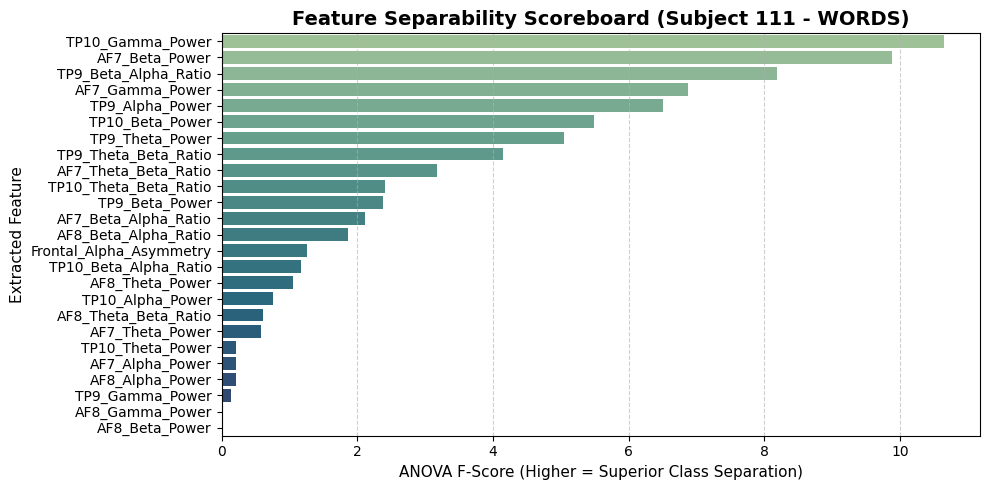


💾 Feature matrix successfully generated at: /content/muse_extracted_offline_features_words_ID_111.csv
⬇️ Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluates which features produce the highest F-scores (best class separability).
# Saves the resulting dataset and downloads it to your computer.

X = feature_matrix_df.drop('Target_Class', axis=1)
y = feature_matrix_df['Target_Class']

if len(y.unique()) < 2:
    print("❌ Error: Dataset does not contain both Rest and Active task markers.")
else:
    # Run ANOVA F-test
    selector = SelectKBest(score_func=f_classif, k='all')
    selector.fit(X, y)

    scores_df = pd.DataFrame({
        'Feature': X.columns,
        'F_Score': selector.scores_
    }).sort_values(by='F_Score', ascending=False)

    print("🏆 Top Ranked Features by ANOVA F-Score:")
    for idx, row in scores_df.iterrows():
        print(f"  - {row['Feature']:<30} : F-Score = {row['F_Score']:.2f}")

    # Plot the Separability Scoreboard
    plt.figure(figsize=(10, 5), dpi=100)
    sns.barplot(data=scores_df, x='F_Score', y='Feature', palette='crest', hue='Feature', legend=False)
    plt.title(f"Feature Separability Scoreboard (Subject {subject_id} - {task_type.upper()})", fontsize=14, fontweight='bold')
    plt.xlabel("ANOVA F-Score (Higher = Superior Class Separation)", fontsize=11)
    plt.ylabel("Extracted Feature", fontsize=11)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Save to Colab's temporary memory
    output_filename = f"muse_extracted_offline_features_{task_type}_ID_{subject_id}.csv"
    output_path = os.path.join(target_dir, output_filename)
    feature_matrix_df.to_csv(output_path, index=False)
    print(f"\n💾 Feature matrix successfully generated at: {output_path}")

    # Automatically download the file to your local computer
    from google.colab import files
    print("⬇️ Triggering browser download...")
    files.download(output_path)

# **Install Dependencies and Upload Feature Matrix**

In [ ]:
# Run this cell to initialize the machine learning environment.
# Upload the CSV feature matrix you generated in the previous step.

import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
)

print("✅ Machine Learning environment initialized.")
print("⬇️ Please click below to upload your extracted feature CSV file(s):")
uploaded = files.upload()

✅ Machine Learning environment initialized.
⬇️ Please click below to upload your extracted feature CSV file(s):


Saving muse_extracted_offline_features_words_ID_111.csv to muse_extracted_offline_features_words_ID_111 (1).csv


# **Subject and Task Configuration**

In [ ]:
# Select the evaluation task to match the file you just uploaded.

task_type = "words" # @param ["math", "words"]
subject_id = "111" # Used for matching the filename

target_dir = "/content"
print("=" * 60)
print(f"🧠 ML Training Target: {task_type.upper()}")
print("=" * 60)

feature_file_path = os.path.join(target_dir, f"muse_extracted_offline_features_{task_type}_ID_{subject_id}.csv")

if not os.path.exists(feature_file_path):
    print(f"❌ Warning: Could not find '{feature_file_path}'.")
    print("Check if you uploaded the correct file or if the Subject ID matches.")
else:
    print(f"✅ Found feature matrix: {os.path.basename(feature_file_path)}")

🧠 ML Training Target: WORDS
✅ Found feature matrix: muse_extracted_offline_features_words_ID_111.csv


# **Define Evaluation Metrics**

In [ ]:
# This block sets up 5-Fold Cross-Validation and calculates the Information Transfer Rate (ITR).

def calculate_itr(n_classes, accuracy, trial_duration_sec):
    if accuracy == 1.0:
        b = np.log2(n_classes)
    elif accuracy <= (1.0 / n_classes):
        b = 0.0
    else:
        b = (accuracy * np.log2(accuracy) +
             (1.0 - accuracy) * np.log2((1.0 - accuracy) / (n_classes - 1.0)) +
             np.log2(n_classes))
    return max(0.0, b * (60.0 / trial_duration_sec))

def evaluate_model(model, X_train, y_train, X_test, y_test):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_accuracies = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        model.fit(X_train[train_idx], y_train[train_idx])
        preds = model.predict(X_train[val_idx])
        cv_accuracies.append(accuracy_score(y_train[val_idx], preds))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]

    return {
        'cv_mean': np.mean(cv_accuracies),
        'cv_std': np.std(cv_accuracies),
        'acc': accuracy_score(y_test, y_pred),
        'bal_acc': balanced_accuracy_score(y_test, y_pred),
        'kappa': cohen_kappa_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_probs),
        'itr': calculate_itr(2, accuracy_score(y_test, y_pred), 2.0)
    }

print("✅ Evaluation logic loaded.")

✅ Evaluation logic loaded.


# **Train and Compare Algorithms**

In [ ]:
# The data is split 80/20. We train LDA, SVM, Random Forest, and Logistic Regression simultaneously.

df = pd.read_csv(feature_file_path)
X = df.drop('Target_Class', axis=1).values
feature_names = df.drop('Target_Class', axis=1).columns.tolist()
y = df['Target_Class'].values

# Stratified Split & Standard Scaling (Crucial for SVM & LR)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'LDA': LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Reg': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"🧠 Training {name}...")
    results[name] = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test)

# Compile Scoreboard
comp_df = pd.DataFrame(results).T
print("\n🏆 Head-to-Head Holdout Accuracy:")
print(comp_df[['cv_mean', 'acc', 'auc', 'itr']].sort_values(by='acc', ascending=False))

🧠 Training LDA...
🧠 Training SVM (RBF)...
🧠 Training Random Forest...
🧠 Training Logistic Reg...

🏆 Head-to-Head Holdout Accuracy:
                cv_mean       acc       auc        itr
SVM (RBF)      0.669591  0.833333  0.847222  10.499327
LDA            0.637427  0.750000  0.763889   5.661656
Logistic Reg   0.649708  0.750000  0.756944   5.661656
Random Forest  0.606433  0.708333  0.770833   3.874066


# **Visualize Results and Export Production Models**

/tmp/ipykernel_657/57070307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comp_df.index, y=comp_df['acc'] * 100, palette='magma')


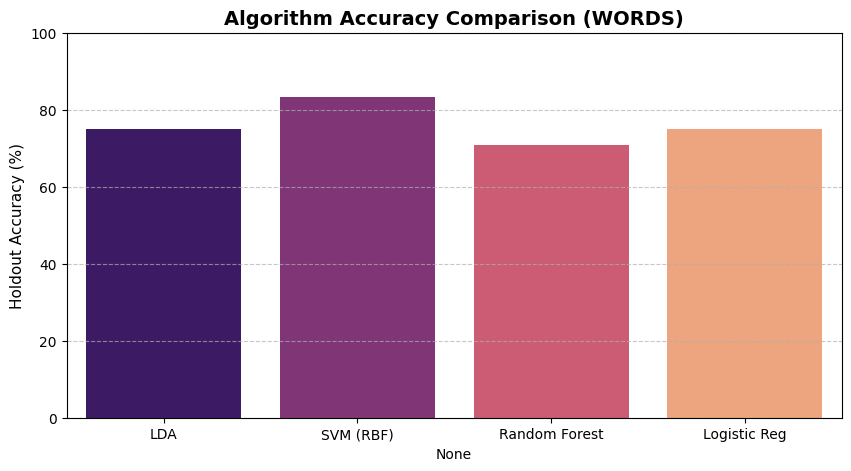


📦 Packaging complete! Triggering download for: bci_production_models_words_ID_111.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Renders a performance comparison chart and automatically zips/downloads the trained model files.

plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(x=comp_df.index, y=comp_df['acc'] * 100, palette='magma')
plt.title(f"Algorithm Accuracy Comparison ({task_type.upper()})", fontsize=14, fontweight='bold')
plt.ylabel("Holdout Accuracy (%)", fontsize=11)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Serialize and save all models
saved_files = []
for name, model in models.items():
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    out_name = f"bci_model_{task_type}_{safe_name}.joblib"
    joblib.dump({'scaler': scaler, 'model': model, 'feature_names': feature_names}, out_name)
    saved_files.append(out_name)

# Zip and trigger download
import zipfile
zip_name = f"bci_production_models_{task_type}_ID_{subject_id}.zip"
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for f in saved_files:
        zipf.write(f)

print(f"\n📦 Packaging complete! Triggering download for: {zip_name}")
files.download(zip_name)